In [4]:
#Comparación experimental

#PROBLEMA: Queremos comparar puntos relativos entre curva ideal y curva real. 
#csv tiene 180 puntos, tracker saca aprox 5000-8000. Vamos a parametrizar ambas curvas y compararlas a un x% (s/1) de completar la trayectoria.

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd


def alinear_trayectoria(x_ideal, y_ideal, x_real, y_real, P_ref,
                          activar_escala=True,
                          activar_rotacion=False,
                          activar_traslacion=True):
    """
    Escala, rota y traslada la trayectoria real (Tracker, en píxeles)
    para que coincida con el sistema de referencia de la trayectoria
    ideal (csv original), usando 2 puntos correspondientes conocidos.

    P_ref: [idx_ideal_1, idx_ideal_2, idx_real_1, idx_real_2]

    """

    pts_ideal_ref = np.array([
        [x_ideal[P_ref[0]], y_ideal[P_ref[0]]],     # punto de referencia 1 (ideal, mm)
        [x_ideal[P_ref[1]], y_ideal[P_ref[1]]],     # punto de referencia 2 (ideal, mm)
    ])

    pts_tracker_ref = np.array([
        [x_real[P_ref[2]], y_real[P_ref[2]]],       # mismo punto físico 1 (Tracker, px)
        [x_real[P_ref[3]], y_real[P_ref[3]]],       # mismo punto físico 2 (Tracker, px)
    ])

    pts_origen = np.asarray(pts_tracker_ref, dtype=float)   # Tracker (px)
    pts_destino = np.asarray(pts_ideal_ref, dtype=float)    # Ideal (mm)

    # --- Centrar ambos conjuntos ---
    centroide_o = pts_origen.mean(axis=0)
    centroide_d = pts_destino.mean(axis=0)
    o_centrado = pts_origen - centroide_o
    d_centrado = pts_destino - centroide_d

    # --- Rotación óptima (SVD / algoritmo de Umeyama-Kabsch) ---
    if activar_rotacion:
        H = o_centrado.T @ d_centrado
        U, S, Vt = np.linalg.svd(H)
        D = np.eye(2)
        if np.linalg.det(Vt.T @ U.T) < 0:
            D[-1, -1] = -1
        R = Vt.T @ D @ U.T
    else:
        R = np.eye(2)
        S = None

    # --- Escala óptima ---
    if activar_escala:
        var_o = np.sum(o_centrado**2)
        if activar_rotacion:
            s = np.sum(S * np.diag(D)) / var_o
        else:
            # Sin rotación: escala óptima en mínimos cuadrados sin rotar
            s = np.sum(o_centrado * d_centrado) / var_o
    else:
        s = 1.0

    # --- Traslación ---
    if activar_traslacion:
        t = centroide_d - s * R @ centroide_o
    else:
        t = np.zeros(2)

    # --- Aplicar transformación a TODA la trayectoria real ---
    puntos_real = np.column_stack([x_real, y_real]).astype(float)
    puntos_real_transformados = (s * (R @ puntos_real.T).T) + t

    x_real_transformado = puntos_real_transformados[:, 0]
    y_real_transformado = puntos_real_transformados[:, 1]

    return x_real_transformado, y_real_transformado


def parametrizar_por_arco(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # --- Eliminar puntos consecutivos duplicados (ds=0) ---
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)

    mask = np.concatenate([[True], ds > 1e-9])  # conserva el primer punto siempre
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        raise ValueError("Muy pocos puntos únicos tras eliminar duplicados.")

    # --- Recalcular longitud de arco con los puntos ya filtrados ---
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate([[0], np.cumsum(ds)])
    s_norm = s / s[-1]

    fx = interp1d(s_norm, x, kind='cubic')
    fy = interp1d(s_norm, y, kind='cubic')
    return fx, fy


def rmse_trayectorias(x_ideal, y_ideal, x_real, y_real, n_puntos=1000):
    fx_ideal, fy_ideal = parametrizar_por_arco(x_ideal, y_ideal)
    fx_real, fy_real = parametrizar_por_arco(x_real, y_real)
    
    s_common = np.linspace(0, 1, n_puntos)
    
    x_i, y_i = fx_ideal(s_common), fy_ideal(s_common)
    x_r, y_r = fx_real(s_common), fy_real(s_common)
    
    errores = np.sqrt((x_i - x_r)**2 + (y_i - y_r)**2)
    rmse = np.sqrt(np.mean(errores**2))
    
    # --- R^2 ---
    ss_res = np.sum((x_i - x_r)**2 + (y_i - y_r)**2)
    ss_tot = np.sum((x_i - np.mean(x_i))**2 + (y_i - np.mean(y_i))**2)
    r2 = 1 - ss_res/ss_tot
    
    return rmse, r2, errores, s_common


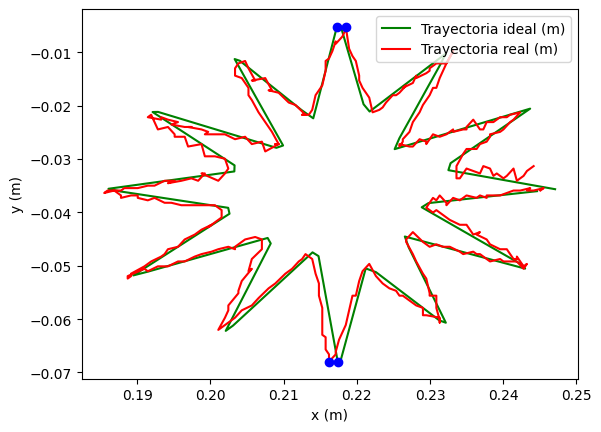

RMSE: 3.0318 mm
R^2: 0.9814


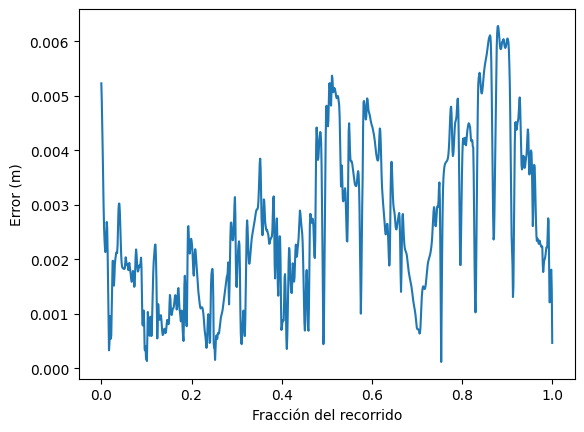

In [7]:
#Leo trayectorias
df_ideal = pd.read_csv("data star.csv")
x_ideal = df_ideal["x_m"].to_numpy()
y_ideal = df_ideal["y_m"].to_numpy()

df_tracker = pd.read_csv("05def.csv", sep=";", decimal=",")
x_tracker = df_tracker["x"].to_numpy() # ajusta nombres según cómo exportó Tracker
y_tracker = df_tracker["y"].to_numpy()

#Escalo, traslado, roto puntos de tracker para ajustarse a reales. Debo ingresar 4 puntos coincidentes(en funcion)
#indices de puntos de referencia:
         #Ideal      #Real
         
psk06=[43, 135, 1183, 3286]
psk05=[43, 135, 120, 332]
p05def=[43, 135, 107, 319]
P_ref = p05def
x_real_mm, y_real_mm = alinear_trayectoria(x_ideal, y_ideal, x_tracker, y_tracker, P_ref)

#Parametrizo y comparo:

rmse, r2, errores, s = rmse_trayectorias(x_ideal, y_ideal, x_real_mm, y_real_mm)

# Visualizar dónde se desvía más el movimiento real
import matplotlib.pyplot as plt

#Graficar trayectorias sobrepuestas

plt.plot(x_ideal, y_ideal, label="Trayectoria ideal (m)", color="green")
plt.plot(x_real_mm, y_real_mm, label="Trayectoria real (m)", color="red")
plt.plot(x_ideal[P_ref[0]], y_ideal[P_ref[0]], 'bo') #Superior ideal
plt.plot(x_ideal[P_ref[1]], y_ideal[P_ref[1]], 'bo') #Inferior ideal
plt.plot(x_real_mm[P_ref[2]], y_real_mm[P_ref[2]], 'bo') #Superior real
plt.plot(x_real_mm[P_ref[3]], y_real_mm[P_ref[3]], 'bo') #Inferior real
plt.legend(loc="upper right")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

plt.plot(s, errores)
plt.xlabel("Fracción del recorrido")
plt.ylabel("Error (m)")
rmse_mm = round(float(rmse*1000), 4)
r2 = round(float(r2), 4)
print(f"RMSE: {rmse_mm} mm")
print(f"R^2: {r2}")
plt.show()
